In [2]:
import pandas as pd
import numpy as np

print('memuat datasets..\n')

df1=pd.read_csv("../data/TB_SymptdataApril2024.csv")
print('datasets dimuat..\n')

df1.info()

memuat datasets..

datasets dimuat..

<class 'pandas.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 14 columns):
 #   Column                                                     Non-Null Count  Dtype
---  ------                                                     --------------  -----
 0   fever for two weeks                                        2167 non-null   int64
 1   coughing blood                                             2167 non-null   int64
 2   sputum mixed with blood                                    2167 non-null   int64
 3   night sweats                                               2167 non-null   int64
 4   chest pain                                                 2167 non-null   int64
 5   back pain in certain parts                                 2167 non-null   int64
 6   shortness of breath                                        2167 non-null   int64
 7   weight loss                                                2167 non-null   int64
 8   b

In [7]:
df1.head(10)

,fever for two weeks,coughing blood,sputum mixed with blood,night sweats,chest pain,back pain in certain parts,shortness of breath,weight loss,body feels tired,lumps that appear around the armpits and neck,cough and phlegm continuously for two weeks to four weeks,swollen lymph nodes,loss of appetite,Prediction
0,1,0,0,0,1,0,0,1,1,0,1,1,0,1
1,1,1,0,1,0,1,1,0,1,0,0,0,1,1
2,1,1,0,1,0,1,0,0,0,0,0,1,0,1
3,0,1,1,1,0,0,1,1,0,0,1,1,0,1
4,1,1,0,1,0,1,0,1,0,1,1,1,1,1
5,0,0,0,1,0,1,1,1,1,0,0,1,1,1
6,0,0,0,1,0,1,1,1,1,1,0,0,0,1
7,0,1,1,0,1,1,1,0,0,0,0,1,1,1
8,0,1,0,1,0,1,1,1,1,1,0,0,0,1
9,1,1,1,0,0,0,0,1,0,1,0,1,1,1


In [16]:
counts=(df1['Prediction'].value_counts())
print('jumlah data per kategori:\n',counts)

jumlah data per kategori:
 Prediction
1    1122
0    1045
Name: count, dtype: int64


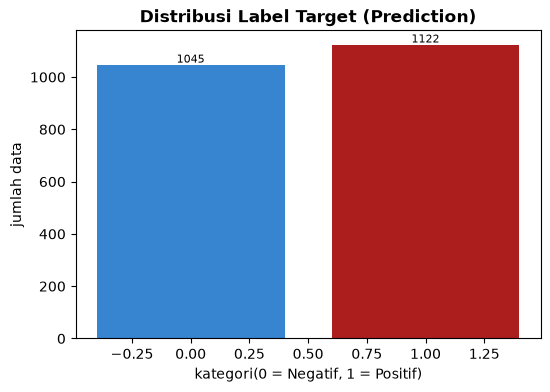

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=["#AC1E1E","#3784D1"])
plt.bar_label(plt.bar(counts.index, counts.values, color=['#AC1E1E','#3784D1']), label_type='edge', fontsize=8)

plt.title('Distribusi Label Target (Prediction)', fontsize=12, fontweight='bold')
plt.xlabel('kategori(0 = Negatif, 1 = Positif)')
plt.ylabel('jumlah data')

plt.show()


In [19]:
df1.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
fever for two weeks,2167.0,0.297647,0.457329,0.0,0.0,0.0,1.0,1.0
coughing blood,2167.0,0.250115,0.433179,0.0,0.0,0.0,0.5,1.0
sputum mixed with blood,2167.0,0.290263,0.453988,0.0,0.0,0.0,1.0,1.0
night sweats,2167.0,0.394555,0.488868,0.0,0.0,0.0,1.0,1.0
chest pain,2167.0,0.304107,0.460134,0.0,0.0,0.0,1.0,1.0
back pain in certain parts,2167.0,0.398246,0.489650,0.0,0.0,0.0,1.0,1.0
shortness of breath,2167.0,0.321181,0.467038,0.0,0.0,0.0,1.0,1.0
weight loss,2167.0,0.321643,0.467215,0.0,0.0,0.0,1.0,1.0
body feels tired,2167.0,0.447162,0.497315,0.0,0.0,0.0,1.0,1.0
lumps that appear around the armpits and neck,2167.0,0.294416,0.455885,0.0,0.0,0.0,1.0,1.0


In [21]:
print('jumlah data duplikat:', df1.duplicated().sum())

jumlah data duplikat: 1179


In [28]:
df1=df1.rename(columns={'Prediction': 'prediction'})

print("nama kolom setelah diubah:", df1.columns)

nama kolom setelah diubah: Index(['fever for two weeks', 'coughing blood', 'sputum mixed with blood',
       'night sweats ', 'chest pain', 'back pain in certain parts ',
       'shortness of breath', 'weight loss ', 'body feels tired',
       'lumps that appear around the armpits and neck',
       'cough and phlegm continuously for two weeks to four weeks',
       'swollen lymph nodes', 'loss of appetite', 'prediction'],
      dtype='str')


In [29]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 14 columns):
 #   Column                                                     Non-Null Count  Dtype
---  ------                                                     --------------  -----
 0   fever for two weeks                                        2167 non-null   int64
 1   coughing blood                                             2167 non-null   int64
 2   sputum mixed with blood                                    2167 non-null   int64
 3   night sweats                                               2167 non-null   int64
 4   chest pain                                                 2167 non-null   int64
 5   back pain in certain parts                                 2167 non-null   int64
 6   shortness of breath                                        2167 non-null   int64
 7   weight loss                                                2167 non-null   int64
 8   body feels tired                       

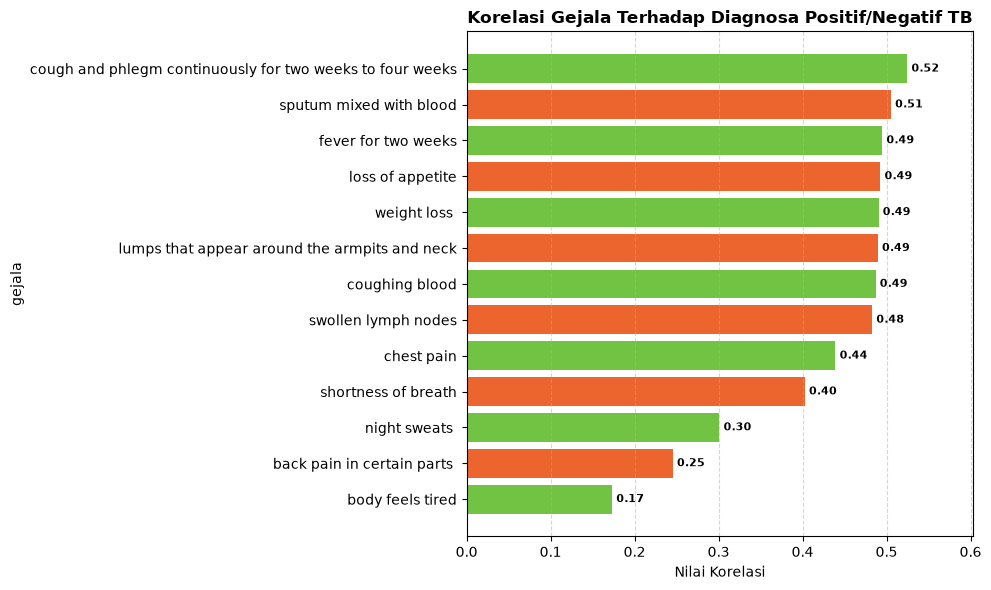

In [41]:
corr_target=(
    df1.corr()['prediction'].drop('prediction').sort_values(ascending=True)
)

plt.figure(figsize=(10,6))
bars= plt.barh(corr_target.index, corr_target.values, color=["#72C343","#EC642E"])

plt.bar_label(bars, fmt='%.2f', fontsize=8, padding =3, fontweight='bold')
plt.title('Korelasi Gejala Terhadap Diagnosa Positif/Negatif TB', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Korelasi')
plt.ylabel('gejala')
plt.xlim(0, max(corr_target.values) * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()